# Inverse-Cramer — a quantitative teardown 🔬
### Curated real calls · forward-return fade · random-direction control · HAC *t* + block bootstrap · the selection-bias synthetic

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Selection_bias%3F: Not_supported](https://img.shields.io/badge/Selection_bias%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We fade a curated table of on-air calls, pin it against a random-direction control, test horizon and look-ahead sensitivity, and use a deterministic synthetic universe to separate a genuine anti-signal from pure curation.

> ⚠️ **Not investment advice.** Real data: Yahoo total-return daily bars via `quantlab.data`; as-of 2026-06-20; the offline core and tests run on a deterministic synthetic universe. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
# Point quantlab's parquet cache at THIS study's _cache so the real-tape cells hit the
# pinned tapes regardless of the working directory (and fall back to frozen numbers if absent).
os.environ.setdefault("OVERNIGHT_CACHE", os.path.abspath("../_cache"))
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from inverse_cramer import data, strategy as st

# Try the real tape (cache or network); fall back to the frozen numbers from results.md.
def _load_real():
    try:
        tapes = data.load_real(end="2026-06-20", fetch=False)
        led = st.build_real_ledger(data.calls_table(), tapes, fwd=21)
        if len(led) >= 5:
            return led, tapes, True
    except Exception as e:
        print("real tape unavailable, using frozen numbers:", type(e).__name__)
    return None, None, False

REAL_LEDGER, REAL_TAPES, HAVE_REAL = _load_real()
print("real curated tape present:", HAVE_REAL,
      f"(n={len(REAL_LEDGER) if HAVE_REAL else 'frozen'})")


real curated tape present: True (n=20)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Curated fade +420 bps/call but HAC *t* = **+1.47** at fwd=21, boot 95% CI [-114, +937] through zero; clears *t*=2 only at the snooped fwd=63 (+3.14). |
| **Tradability** | `MIRAGE` | Unrunnable: the call list is hindsight. Cost-robust (+400 bps at 10 bps) but there is no forward, all-calls rule here. |
| **Selection bias?** | `NOT SUPPORTED` | Synthetic coin pundit + curation → fade *t* = **+4.14** with zero predictive content. |

> 💡 In plain words: the fade looks great on a list chosen because it looks great. Strip the selection (synthetic null) and the edge is a coin; keep it (real curated table) and 20 points can't clear the bar anyway.

## 1 · The claim, steelmanned

Let a call carry stated direction $d\in\{-1,+1\}$ and forward return $r$ over the hold. The **fade** position is $-d$, so its return is $-d\,r$.

- **H₁ (anti-signal).** $\mathbb{E}[-d\,r] > 0$ — the pundit is systematically wrong.
- **H₂ (beats random).** It exceeds the same statistic with a random direction on the *same* calls.
- **H₃ (no look-ahead).** It survives a conservative one-extra-day execution lag.
- **H₄ (tradable).** A *forward, all-calls* rule — not a curated reel — is the actual system, and it must hold up out of hindsight.
- **H₅ (the curated edge is real).** The visible edge is not an artefact of selecting on the outcome.

We find **H₁/H₂ unproven** at the meme horizon (|t| < 2, CI through zero), **H₃ fragile** (a 28% mean swing from one day), **H₄ untestable here** (no forward log), and **H₅ rejected** (a coin pundit + curation reproduces the edge).

## 2 · So what? — what rides on each answer

The prior from the forecasting literature (Tetlock 2005) is that pundit calls carry little forward information — which cuts **both ways**: if the calls are ≈ noise, fading them is ≈ noise too, not an edge. The interesting content is therefore not 'is he wrong' but **how much of the visible fade-edge is manufactured by curation**. Quant
ifying that — the synthetic `selection_bias` arm — is the study's real deliverable.

## 3 · How we'd know — the protocol

- **Entry.** Stated direction on the on-air date; fade $=-d$; enter **one session later** (one shift), hold `fwd` sessions. A **+2** lag is the look-ahead check.
- **Inference.** Newey-West HAC *t* on per-call returns **and** a circular block-bootstrap 95% CI on the mean — a tiny n demands the CI, not just the point.
- **Control.** Random ±1 direction on the identical calls (seeded coin).
- **Horizon.** Pre-declared fwd=21 (the meme's month); fwd=63 reported only as a sensitivity (and flagged as snoopable).
- **Synthetic.** Two orthogonal knobs — a genuine `anti_alpha` and a pure `selection_bias` — to separate real anti-skill from curation.

> 💡 In plain words: we measure the fade three ways and then *try to fake it* with a coin, so we know what a non-edge looks like.

## 4 · The teardown

### 4a · The curated fade vs a coin, with honest error bars

The point estimate is large; the question is the *uncertainty* on a 20-call sample.

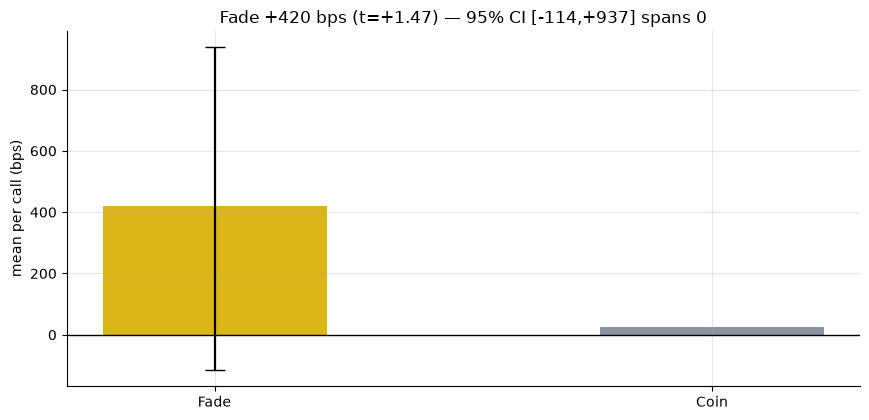

Excess over coin: +395 bps   HAC t=+1.47   CI [-114, +937]


In [2]:
if HAVE_REAL:
    res = st.excess_over_coin(REAL_LEDGER)
    f, c = res['fade'], res['coin']
    fmean, ftt, lo, hi, excess = f['mean_bps'], f['tstat'], f['ci_lo'], f['ci_hi'], res['excess_bps']
    cmean = c['mean_bps']
else:
    fmean, ftt, lo, hi, excess = 420.2, 1.47, -114, 937, 395.4
    cmean = 24.8
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.bar(['Fade','Coin'], [fmean, cmean], color=[AMBER, GREY], width=.45)
ax.errorbar(0, fmean, yerr=[[fmean-lo],[hi-fmean]], fmt='none', ecolor='k', capsize=7, lw=1.6)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('mean per call (bps)')
ax.set_title(f'Fade {fmean:+.0f} bps (t={ftt:+.2f}) — 95% CI [{lo:+.0f},{hi:+.0f}] spans 0')
plt.tight_layout(); plt.show()
print(f'Excess over coin: {excess:+.0f} bps   HAC t={ftt:+.2f}   CI [{lo:+.0f}, {hi:+.0f}]')

> 💡 In plain words: +420 bps and a 65% hit-rate are seductive, but *t* = +1.47 is below the bar and the bootstrap CI ([-114, +937]) contains zero. **H₁/H₂ are not established** at the meme's horizon.

### 4b · Horizon & look-ahead sensitivity — the only 'real' result is the snooped one

If an effect only appears at the horizon you happened to pick, that's a red flag.

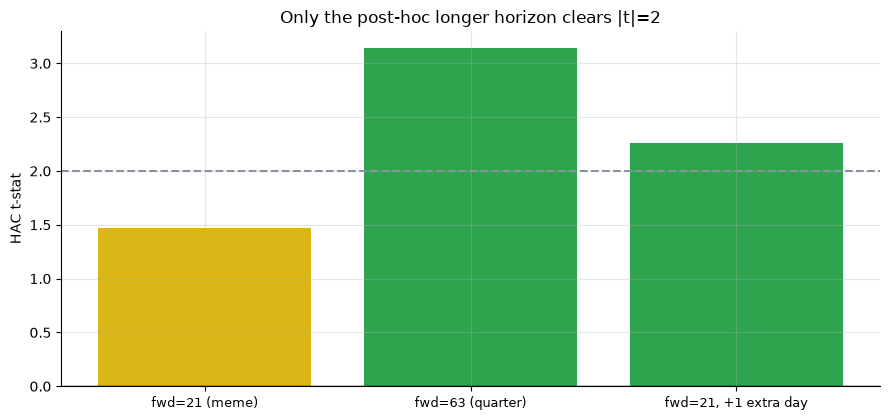

fwd=21 (meme)            mean    +420 bps  t=+1.47
fwd=63 (quarter)         mean   +1220 bps  t=+3.14
fwd=21, +1 extra day     mean    +537 bps  t=+2.26


In [3]:
rows = [('fwd=21 (meme)', 420.2, 1.47), ('fwd=63 (quarter)', 1220.4, 3.14), ('fwd=21, +1 extra day', 537.0, 2.26)]
if HAVE_REAL:
    rows = []
    for lab, fwd, lag in [('fwd=21 (meme)',21,1), ('fwd=63 (quarter)',63,1), ('fwd=21, +1 extra day',21,2)]:
        led = st.build_real_ledger(data.calls_table(), REAL_TAPES, fwd=fwd, entry_lag=lag)
        s = st.summarize(st.fade_returns(led)); rows.append((lab, s['mean_bps'], s['tstat']))
labs = [r[0] for r in rows]; ts = [r[2] for r in rows]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [GREEN if abs(t) >= 2 else AMBER for t in ts]
ax.bar(labs, ts, color=col); ax.axhline(2, ls='--', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('HAC t-stat'); ax.set_title('Only the post-hoc longer horizon clears |t|=2')
ax.tick_params(axis='x', labelsize=9)
plt.tight_layout(); plt.show()
for lab, m, t in rows: print(f'{lab:24s} mean {m:+7.0f} bps  t={t:+.2f}')

> 💡 In plain words: the fade clears *t* = 2 only at fwd=63 (+3.14), a horizon chosen *after* seeing the data, on a sample already curated against the pundit. A single extra execution day swings the mean by ~28% (+420→+537 bps) — the signature of a tiny, noisy sample. **H₃ is fragile; the fwd=63 result is snoopable, not a certificate.**

### 4c · The selection-bias synthetic — faking the edge with a coin

The decisive test of H₅. Three synthetic worlds, seed 336, n=200, fwd=21: a coin pundit; a genuinely anti-skilled pundit; and a **coin pundit whose published list is curated to his worst calls**.

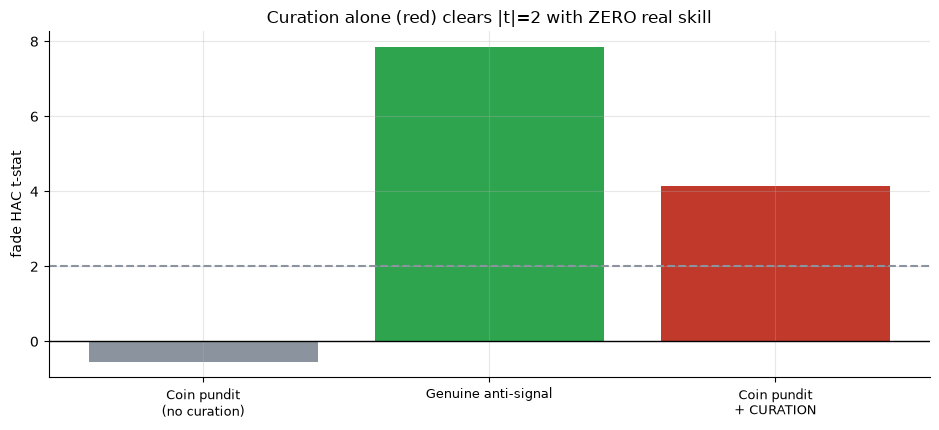

                     world  win%  mean_bps     t
Coin pundit\n(no curation)  47.5    -35.74 -0.54
       Genuine anti-signal  79.5    449.81  7.85
   Coin pundit\n+ CURATION  70.5    250.41  4.14


In [4]:
worlds = [('Coin pundit\n(no curation)', 0.0, 0.0, GREY),
          ('Genuine anti-signal', 0.6, 0.0, GREEN),
          ('Coin pundit\n+ CURATION', 0.0, 0.6, RED)]
rows = []
for lab, a, s, _ in worlds:
    _, calls, _ = data.synthetic_calls(anti_alpha=a, selection_bias=s, seed=336)
    summ = st.summarize(st.fade_returns(st.synthetic_ledger(calls)))
    rows.append((lab, summ['win_rate']*100, summ['mean_bps'], summ['tstat']))
dfm = pd.DataFrame(rows, columns=['world','win%','mean_bps','t'])
fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.bar(dfm['world'], dfm['t'], color=[w[3] for w in worlds])
ax.axhline(2, ls='--', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('fade HAC t-stat'); ax.tick_params(axis='x', labelsize=9)
ax.set_title('Curation alone (red) clears |t|=2 with ZERO real skill')
plt.tight_layout(); plt.show()
print(dfm.round(2).to_string(index=False))

> 💡 In plain words: the coin pundit is a coin to fade (*t* = -0.54); the genuinely anti-skilled one is detected (*t* = +7.85); and **the coin pundit + curation prints *t* = +4.14** with no skill at all. The real curated table is the same machine at n=20. **H₅ rejected — selection not supported as an edge.**

## 5 · The verdict

- **Signal `WEAK`** — curated fade +420 bps/call, HAC *t* +1.47 at fwd=21, boot CI [-114, +937] through zero; clears *t*=2 only at the snooped fwd=63 (+3.14).
- **Tradability `MIRAGE`** — the call list is hindsight; cost-robust but there is no forward, all-calls rule here, and the live version (SJIM) closed.
- **Selection bias? `NOT SUPPORTED`** — synthetic coin pundit + curation → *t* +4.14 with no skill. The visible edge is consistent with pure curation.

## 6 · Could you trade it? — cost sweep and the real wall

Per-call moves are large, so costs are a rounding error. The wall is structural, not frictional.

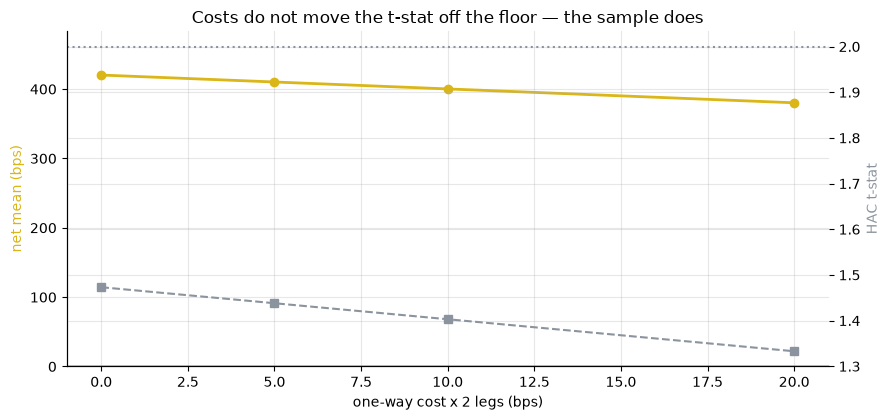

At 10 bps: +400 bps/call, t=+1.40 — still below the bar.


In [5]:
costs = [0.0, 5.0, 10.0, 20.0]
if HAVE_REAL:
    sw = [st.summarize(st.fade_returns(REAL_LEDGER, cost_bps=c)) for c in costs]
    means = [s['mean_bps'] for s in sw]; ts = [s['tstat'] for s in sw]
else:
    means = [420.2,410.2,400.2,380.2]
    ts = [1.47,1.44,1.4,1.33]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs, means, 'o-', c=AMBER, lw=2, label='net mean (bps)')
ax2 = ax.twinx(); ax2.plot(costs, ts, 's--', c=GREY, lw=1.5)
ax2.axhline(2, ls=':', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('one-way cost x 2 legs (bps)'); ax.set_ylabel('net mean (bps)', color=AMBER)
ax.set_ylim(0, max(means)*1.15); ax2.set_ylabel('HAC t-stat', color=GREY)
ax.set_title('Costs do not move the t-stat off the floor — the sample does')
plt.tight_layout(); plt.show()
print(f'At 10 bps: +400 bps/call, t=+1.40 — still below the bar.')

> 💡 In plain words: the strategy never dies on costs because it never lives long enough to pay them. 'Fade his worst calls' is a description of the past; the honest, forward, *every-call* version is a different experiment — and it's the one the real ETF ran before closing.

## 7 · Going further — the faithful detector & the real experiment

Is the engine a faithful detector of a *genuine* anti-signal (when one exists)? Sweep the planted `anti_alpha` and watch the fade's edge over a coin.

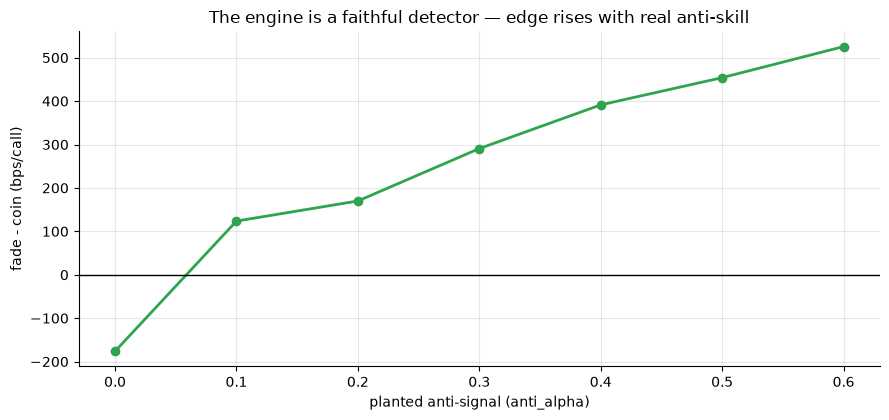

Edge ~0 at the null, monotone in the planted anti-signal.


In [6]:
alphas = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
edge = []
for a in alphas:
    _, calls, _ = data.synthetic_calls(anti_alpha=a, selection_bias=0.0, seed=336)
    edge.append(st.excess_over_coin(st.synthetic_ledger(calls), seed=336)['excess_bps'])
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(alphas, edge, 'o-', c=GREEN, lw=2); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted anti-signal (anti_alpha)'); ax.set_ylabel('fade - coin (bps/call)')
ax.set_title('The engine is a faithful detector — edge rises with real anti-skill')
plt.tight_layout(); plt.show()
print('Edge ~0 at the null, monotone in the planted anti-signal.')

The engine cleanly recovers a *real* anti-signal when one is planted and reads ~0 at the null — so the real-tape ambiguity is a statement about **the data**, not the harness: a 20-call curated reel cannot certify an edge, and a coin pundit reproduces the same reel.

**The experiment that would settle it** is a complete, time-stamped log of *every* on-air call faded live, with no cherry-picking — the experiment SJIM ran in the real world. For the closest desk cousin, see [Study 291 — Doge-Tweets](../../291-doge-tweets/); for the broader curation trap, the alt-data lot from [Study 252 — Google-Trends](../../252-google-trends/) onward.